# 🏦 Loan Default Prediction using Naïve Bayes



## 🔁 Workflow

```
Load Data → EDA → Preprocessing → Train/Test Split →
Train Model → Evaluate → Visualize Results
```

##  Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



##  Step 2: Load the Dataset

In [3]:
df = pd.read_csv('loan_data.csv')
# df.shape
df.isnull().sum()
df.dropna(inplace = True)

##  Step 3: Exploratory Data Analysis (EDA)

<Axes: xlabel='loan_status', ylabel='count'>

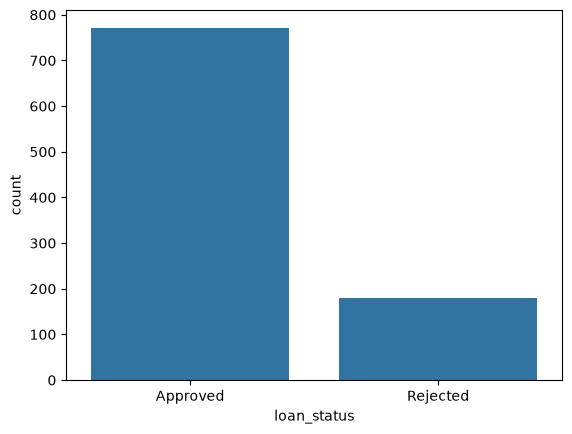

In [4]:
# Basic info
df.info
# Statistical summary
df.describe()
# Missing values
df.isnull().sum()
# Target variable distribution
df['loan_status'].value_counts()

# Correlation heatmap (numeric columns only)
sns.countplot(data = df, x ='loan_status')

## 🛠️ Step 4: Data Preprocessing

> **Why preprocessing?**  
> Naïve Bayes (GaussianNB) works with **numeric values only**.  
> We need to convert categorical columns (text) into numbers using **Label Encoding/ oneHot Encoding**.

In [5]:
df_copy = df.copy()
df_copy = df_copy.drop('applicant_id', axis = 1)

In [6]:
# Identify categorical columns
cat_col = df_copy.select_dtypes(include='object').columns.drop('loan_status')
cat_col

Index(['city', 'education', 'employment_type'], dtype='object')

In [7]:
# one hot encoding
df_copy = df.copy()
df_copy = pd.get_dummies(df_copy,
                         columns = cat_col,
                         dtype = int,
                         drop_first= True)
df_copy.head(2)
df_copy.shape

(950, 19)

In [8]:
df_copy = df_copy.drop('applicant_id', axis = 1)


In [9]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()
df_copy['loan_status'] = Le.fit_transform(df_copy['loan_status'])
df_copy['loan_status'].head()

0    0
1    1
2    0
3    0
4    0
Name: loan_status, dtype: int64

In [10]:
X = df_copy.drop('loan_status', axis = 1)
y = df_copy['loan_status']


In [ ]:
# Define Features (X) and Target (y)

## ✂️ Step 5: Train-Test Split

> We split the data into **80% training** and **20% testing**.  
> The model **learns from training data** and is **evaluated on test data** it has never seen.

In [11]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
# Perform class imbalance
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
X_train.shape, y_train.shape

((1048, 17), (1048,))

## 🤖 Step 6: Train the Naïve Bayes Model

> **GaussianNB** assumes features follow a **Normal (Gaussian) distribution**.  
> It calculates the **mean** and **variance** of each feature for each class.

In [13]:
# Initialize and Train the model
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[524.,524.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,154.7
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['age','annual_income','loan_amount',...,'employment_type_Freelancer', 'employment_type_Salaried','employment_type_Self-Employed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 17)","[[ 41.06,529674.77,304602.92,..., 0.08, 0.53, 0.25], [ 40.15,564702.48,272274.07,..., 0.01, 0.33, 0.11]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 17)","[[2.89e+02,1.60e+11,6.42e+10,...,1.55e+02,1.55e+02,1.55e+02], [2.38e+02,1.48e+11,3.13e+10,...,1.55e+02,1.55e+02,1.55e+02]]"


In [14]:
y_pred = gnb.predict(X_test)
y_pred[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1])

In [15]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred
})
compare.head(10)

,Actual,Predicted
210,0,0
977,0,0
726,0,1
836,1,0
918,0,0
607,0,1
865,0,1
972,0,0
517,1,1
184,0,1


## 📊 Step 7: Model Evaluation

Accuracy: 0.44904458598726116
Precision: 0.22959183673469388
Recall: 0.6716417910447762
F1 Score: 0.34220532319391633
              precision    recall  f1-score   support

           0       0.81      0.39      0.53       247
           1       0.23      0.67      0.34        67

    accuracy                           0.45       314
   macro avg       0.52      0.53      0.43       314
weighted avg       0.69      0.45      0.49       314



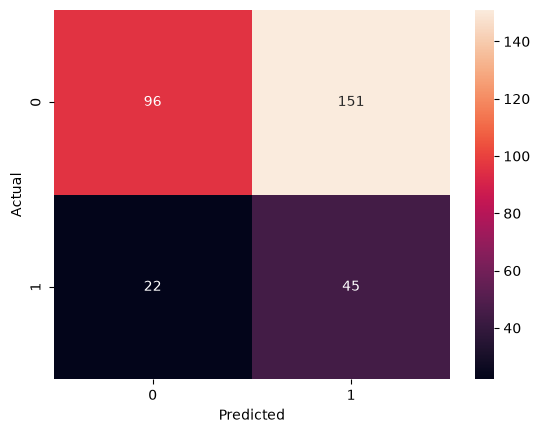

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Prediction on test data
y_pred = gnb.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

# Classification Report
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🔮 Step 8: Predict for a New Loan Applicant

> Let's simulate a **real-world prediction** for a new applicant who has **not been seen by the model** before.

In [17]:
new_applicant = X_test.iloc[[0]]

# Make prediction
prediction = gnb.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Default: Yes")
else:
    print("Loan Default: No")

Loan Default: No


# KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier


### Feature Scaling for KNN

> KNN is sensitive to the scale of the features. We need to standardize the features so that all features contribute equally to the distance calculation.

In [19]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#x=traing data, y=target
print('Features scaled successfully')


Features scaled successfully


### Train the KNN Model

> We will train a K-Nearest Neighbors classifier on the scaled training data.

In [20]:
# Initialize KNN classifier with n_neighbors (e.g., 5)
neigh = KNeighborsClassifier(n_neighbors=3)

# Fit the classifier to the scaled training data
neigh.fit(X_train_scaled, y_train)
print('KNN trained Successfully')

KNN trained Successfully


In [21]:
y_predict=neigh.predict(X_test_scaled)
y_predict[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
compare = pd.DataFrame({
   'Actual' :y_test,
   'Predicted' : y_predict
})
compare.head(10)

,Actual,Predicted
210,0,0
977,0,1
726,0,0
836,1,0
918,0,0
607,0,0
865,0,0
972,0,0
517,1,0
184,0,0



### Make Predictions with KNN

### Evaluate the KNN Model

> We will evaluate the KNN model using a classification report and confusion matrix to understand its performance.

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_predict))


              precision    recall  f1-score   support

           0       0.79      0.77      0.78       247
           1       0.22      0.24      0.23        67

    accuracy                           0.66       314
   macro avg       0.50      0.50      0.50       314
weighted avg       0.67      0.66      0.66       314



### Visualize Confusion Matrix for KNN

Text(50.83333333333333, 0.5, 'Truth')

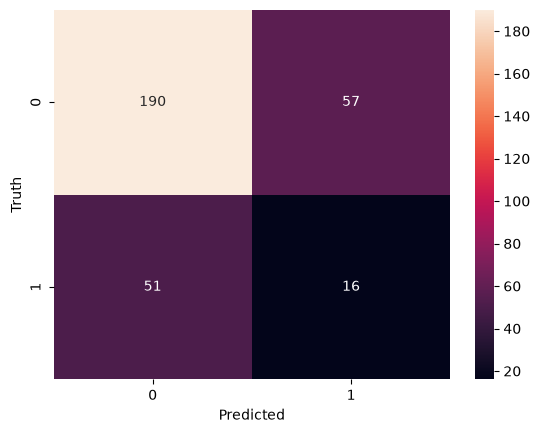

In [24]:
C_knn = confusion_matrix(y_test, y_predict)
sns.heatmap(C_knn, annot = True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')



### Elbow Method for Optimal K (K-Means Clustering)



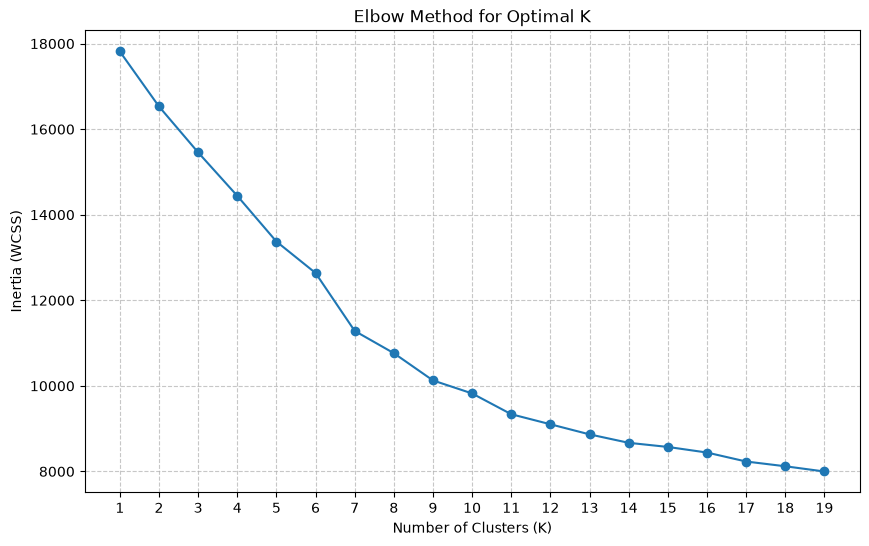

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine a range of K values to test
k_values = range(1, 20) # Testing from 1 to 10 clusters

inertia_values = []

for k in k_values:
    # Ensure X_train_scaled is available and contains your scaled features
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(X_train_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia_values, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values) # Ensure all k_values are shown on x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()